# 1. Problem Statement & Goals 🎯
___
## Problem Statement
Ebuss, a growing e-commerce company with a significant market share in categories like household essentials, personal care, and electronics, aims to scale rapidly and compete with market leaders like Amazon and Flipkart.

To achieve this, Ebuss needs to leverage its vast data on user reviews and ratings. As a Senior Machine Learning Engineer, the core challenge is to build a sentiment-based product recommendation system. This system must not only recommend products based on user behaviors (ratings) but also refine those recommendations by analyzing the sentiment of the textual reviews associated with those products. The ultimate objective is to enhance the user experience by suggesting products that users are most likely to purchase and feel positive about.

## Goals
The project is divided into four main objectives to achieve the problem statement:

### 1. Data Sourcing and Sentiment Analysis

#### Objective: 
* Build a Machine Learning model to classify user reviews as Positive or Negative.

#### Key Tasks:

* Perform Exploratory Data Analysis (EDA), data cleaning, and text preprocessing.

* Extract features using techniques like Bag-of-Words, TF-IDF, or Word Embeddings.

* Train and evaluate at least three of the following classification models: Logistic Regression, Random Forest, XGBoost, or Naive Bayes.

* Select the best-performing model to predict user sentiment.

### 2. Building a Recommendation System

#### Objective: 
* Identify the most effective recommendation technique for the dataset.

#### Key Tasks:

* Develop both User-based and Item-based collaborative filtering recommendation systems.

* Analyze and compare their performance to select the best-suited system.

* Generate an initial list of 20 recommended products for a specific user based on their historical ratings.

### 3. Improving Recommendations using Sentiment Analysis

#### Objective: 
* Create a hybrid "Sentiment-Based Recommendation System."

#### Key Tasks:

* Integrate the chosen Sentiment Analysis model with the Recommendation System.

* Take the top 20 products recommended by the collaborative filtering system.

* Filter and rank these products based on their predicted sentiment scores.

* Output the final top 5 products that have the highest positive sentiment.

### 4. Deployment

#### Objective: 
* Make the solution accessible via a web interface.

#### Key Tasks:

* Build a web application using the Flask framework.

* Create a User Interface (UI) that accepts a username and displays the top 5 recommended products.

* Deploy the end-to-end application (Model + API + UI) on a cloud platform like Heroku.

In [1]:
# Importing Required Libraries
import random
from pathlib import Path
import os

# Data Science Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import WordCloud

# Notebook Setup
from notebook_setup import NotebookInitializer
# Pass the path of the current file to the initializer
initializer = NotebookInitializer(Path(os.getcwd()).resolve())
initializer.setup_environment()

ROOT_DIR already set to: D:\Projects\PRS
Original working directory: d:\Projects\PRS\notebooks
Current working directory changed to the project root: D:\Projects\PRS

--- Directory Structure Setup ---
📂 Root Directory: D:\Projects\PRS
📁 Data Directory: D:\Projects\PRS\data
📥 Raw Data Directory: D:\Projects\PRS\data\raw
📤 Processed Data Directory: D:\Projects\PRS\data\processed
⚙️ Config Manager: ConfigManager(config_path=config.json, model_path=models/)


In [2]:
# Local Utils
from utils import DataFileManager, DataAnalyzer

In [3]:
df = DataFileManager.load_csv_data(initializer.processed_data_dir/'df_final.csv')

Loading data from D:\Projects\PRS\data\processed\df_final.csv
Data successfully loaded. Shape: (29877, 11)


In [4]:
df['reviews_rating'] = pd.to_numeric(df['reviews_rating'])

In [5]:
df.columns

Index(['brand', 'categories', 'manufacturer', 'product_name', 'reviews_date',
       'reviews_doRecommend', 'reviews_rating', 'reviews_text',
       'reviews_title', 'reviews_username', 'user_sentiment'],
      dtype='object')

# 2. Univariate Analysis (Distribution Analysis) 📈

In [6]:
def plot_rating_distribution(df: pd.DataFrame):
    """Creates and displays a count plot of the 'reviews_rating' column.

    This function visualizes the frequency distribution of user-provided review
    ratings, typically on a 1-5 star scale.

    Args:
        df: A pandas DataFrame containing a 'reviews_rating' column with integer
            or categorical rating values.
    """
    # Set a professional style for the plot
    sns.set_theme(style="whitegrid", palette="viridis")

    # Prepare data: ensure ratings are treated as ordered categories
    # Convert to string for countplot for clearer discrete labeling, then sort
    df['reviews_rating'] = df['reviews_rating'].astype(str)
    rating_order = sorted(df['reviews_rating'].unique(), key=int)

    plt.figure(figsize=(10, 6))

    # Use seaborn.countplot for discrete ordinal data (ratings)
    ax = sns.countplot(
        x='reviews_rating',
        data=df,
        order=rating_order,
        edgecolor='black',
        alpha=0.8
    )

    # Set Title and Labels
    ax.set_title(
        'Distribution of Review Ratings',
        fontsize=18,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('Rating (Stars)', fontsize=14)
    ax.set_ylabel('Number of Reviews (Count)', fontsize=14)

    # Add counts and percentages on top of the bars
    total_reviews = len(df)
    for p in ax.patches:
        height = p.get_height()
        # Format the count and the percentage
        count = int(height)
        percentage = f'({100 * height / total_reviews:.1f}%)'

        ax.annotate(
            f'{count}\n{percentage}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

    # Final aesthetic touches and saving
    plt.xticks(rotation=0)
    plt.tight_layout()

    # Save and show the figure
    plt.savefig('review_rating_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

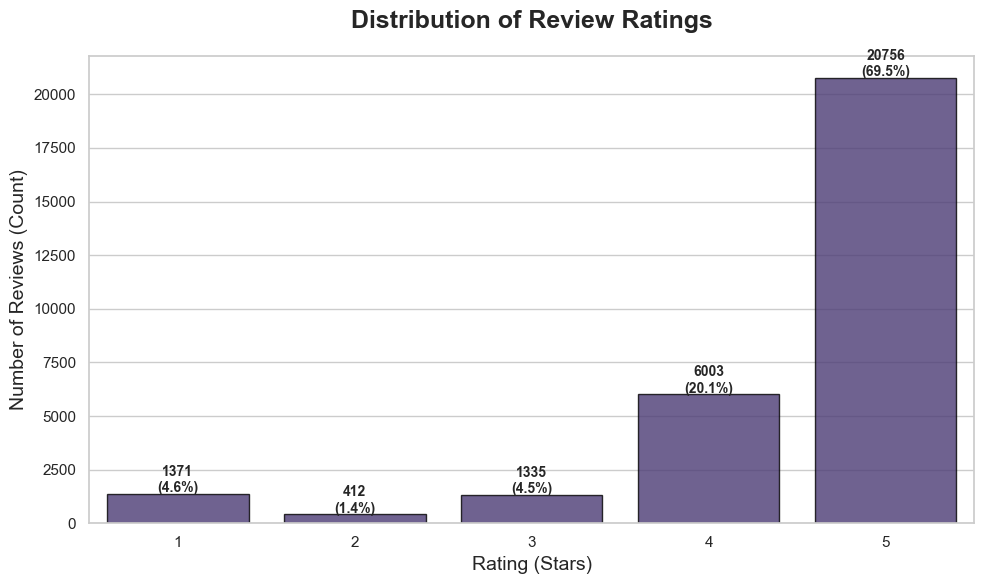

In [7]:
# What is the frequency distribution of review ratings, 
# and is the distribution significantly skewed towards higher or lower star ratings?
plot_rating_distribution(df)

In [8]:
def plot_sentiment_balance(df: pd.DataFrame):
    """Creates and displays a count plot of the 'user_sentiment' column.

    This function visualizes the class distribution (balance) of user sentiments
    (e.g., Positive/Negative), which is critical for machine learning tasks.

    Args:
        df: A pandas DataFrame containing a 'user_sentiment' column with
            categorical values.
    """
    # Set a professional style for the plot
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(8, 6))

    # Define the order and a custom palette for better visual distinction
    sentiment_order = ['Positive', 'Negative']
    # Use a custom palette for Positive (Green/Blue) and Negative (Red/Orange)
    palette_map = {'Positive': sns.color_palette("deep")[2], 'Negative': sns.color_palette("deep")[3]}

    # Use seaborn.countplot for categorical data
    ax = sns.countplot(
        x='user_sentiment',
        data=df,
        order=sentiment_order,
        palette=palette_map,
        edgecolor='black',
        alpha=0.9
    )

    # Set Title and Labels
    ax.set_title(
        'Distribution and Balance of User Sentiment',
        fontsize=16,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('User Sentiment Class', fontsize=14)
    ax.set_ylabel('Number of Reviews (Count)', fontsize=14)

    # Add counts and percentages on top of the bars
    total_reviews = len(df)
    for p in ax.patches:
        height = p.get_height()
        # Format the count and the percentage
        count = int(height)
        percentage = f'({100 * height / total_reviews:.1f}%)'

        ax.annotate(
            f'{count}\n{percentage}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=11,
            fontweight='bold'
        )

    # Final aesthetic touches and saving
    plt.xticks(rotation=0)
    plt.tight_layout()

    # Save and show the figure
    plt.savefig('sentiment_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

C:\Users\outsi\AppData\Local\Temp\ipykernel_6640\3846043322.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


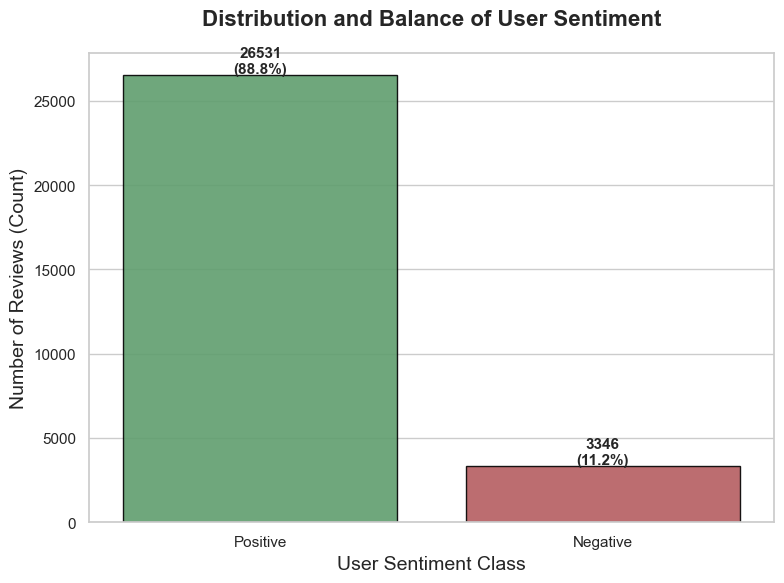

In [9]:
# What is the distribution and class imbalance ratio between positive and negative user sentiments in the dataset?
plot_sentiment_balance(df)

In [10]:
def plot_reviews_over_time(df: pd.DataFrame):
    """Analyzes and plots the temporal trend of review counts.

    The function extracts temporal features (year, month, day of week) and
    then plots the aggregated monthly review count to visualize trends and
    seasonal spikes.

    Args:
        df: A pandas DataFrame containing a 'reviews_date' column.
    """
    # Ensure the date column is in datetime format
    df['reviews_date'] = pd.to_datetime(df['reviews_date'])

    # 1. Extract Temporal Features (as requested)
    df['review_year'] = df['reviews_date'].dt.year
    df['review_month'] = df['reviews_date'].dt.month
    df['review_day_of_week'] = df['reviews_date'].dt.day_name()
    
    # 2. Aggregate Data by Month for Time Series Plotting
    # Set the date column as index and resample to count reviews per month
    reviews_monthly = (
        df.set_index('reviews_date')
        .resample('M')['review_year'] # Use any column for count
        .count()
        .rename('review_count')
    )
    
    # Convert index back to a column for plotting
    reviews_monthly = reviews_monthly.reset_index()

    # Set a professional style for the plot
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(14, 7))

    # Use a line plot for time series data
    ax = sns.lineplot(
        x='reviews_date',
        y='review_count',
        data=reviews_monthly,
        marker='o', # Add markers for clarity at data points
        markersize=5,
        color=sns.color_palette("dark")[0],
        linewidth=2
    )

    # Set Title and Labels
    ax.set_title(
        'Monthly Review Volume Over Time',
        fontsize=18,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel('Total Review Count (Monthly)', fontsize=14)

    # Format X-axis to show years/months clearly
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(12))
    plt.gcf().autofmt_xdate(rotation=45)

    # Add annotation for the peak value
    max_count = reviews_monthly['review_count'].max()
    max_date = reviews_monthly.loc[reviews_monthly['review_count'].idxmax(), 'reviews_date']
    
    ax.annotate(
        f'Peak: {max_count} reviews',
        xy=(max_date, max_count),
        xytext=(max_date + pd.DateOffset(months=3), max_count - 50),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
        fontsize=12,
        fontweight='bold'
    )

    # Final aesthetic touches and saving
    plt.tight_layout()

    # Save and show the figure
    plt.savefig('reviews_over_time_monthly_trend.png', dpi=300, bbox_inches='tight')
    plt.show()

C:\Users\outsi\AppData\Local\Temp\ipykernel_6640\368998969.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')['review_year'] # Use any column for count


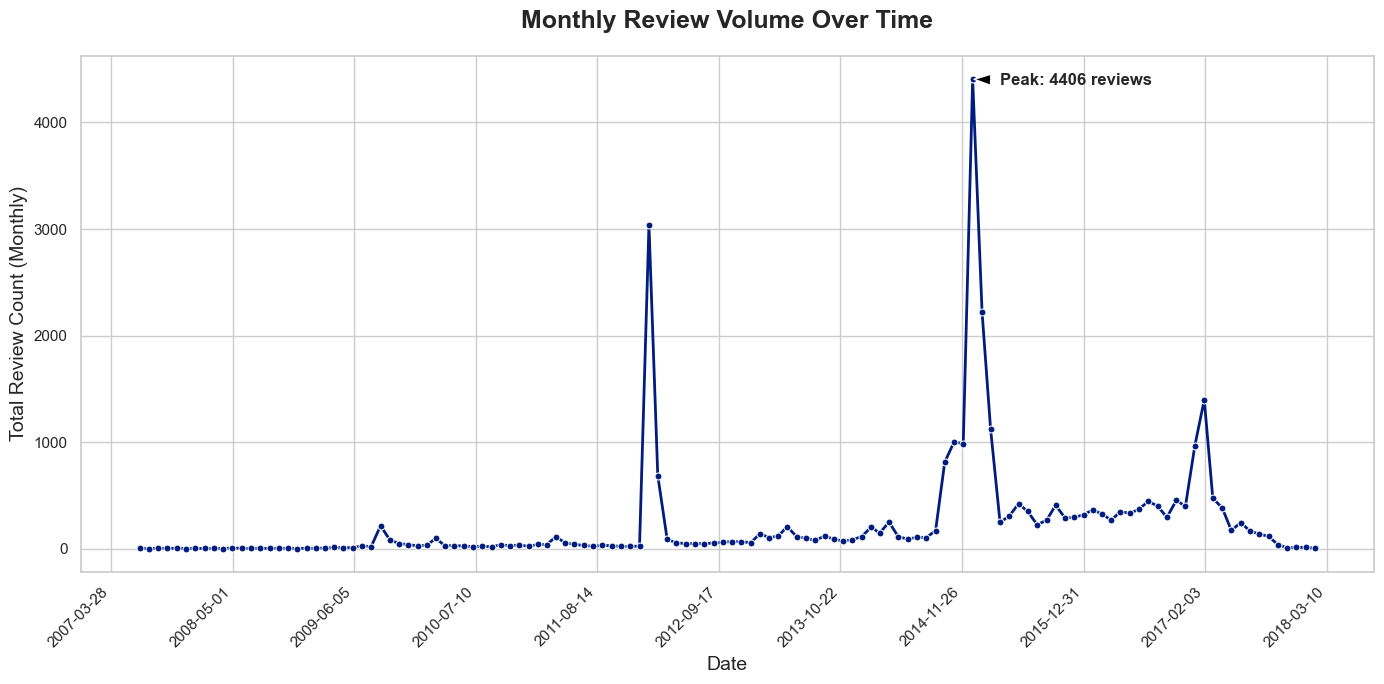

In [11]:
# How has the volume of reviews changed over time, revealing long-term growth trends and short-term seasonal or cyclical spikes in user activity?
plot_reviews_over_time(df)

In [12]:
def plot_top_categorical_features(df: pd.DataFrame, n_top: int = 10):
    """Creates a multi-panel plot showing the counts of the top N most frequent
    values for specified categorical features.

    Args:
        df: A pandas DataFrame containing the categorical features.
        n_top: The number of top categories to display for each feature.
    """
    features = ['brand', 'categories', 'manufacturer']
    n_features = len(features)

    # Set a professional style
    sns.set_theme(style="whitegrid", palette="viridis")

    # Create figure and subplots
    fig, axes = plt.subplots(1, n_features, figsize=(6 * n_features, 7))
    fig.suptitle(
        f'Top {n_top} Most Frequent Entities by Feature',
        fontsize=18,
        fontweight='bold',
        y=1.02
    )

    for i, feature in enumerate(features):
        # Calculate the top N values
        top_n_counts = df[feature].value_counts().nlargest(n_top)
        
        # Calculate percentages for annotation
        total = top_n_counts.sum()
        
        # Create a bar plot
        ax = axes[i]
        sns.barplot(
            x=top_n_counts.values,
            y=top_n_counts.index,
            ax=ax,
            orient='h',
            edgecolor='black',
            alpha=0.9
        )

        # Set labels and title for the subplot
        ax.set_title(
            f'Top {n_top} {feature.title()}',
            fontsize=14,
            fontweight='semibold'
        )
        ax.set_xlabel('Count of Reviews', fontsize=12)
        ax.set_ylabel(feature.title(), fontsize=12)
        
        # Add count and percentage annotations
        for j, (count, label) in enumerate(zip(top_n_counts.values, top_n_counts.index)):
            percentage = (count / total) * 100
            ax.text(
                count + 5, # Position slightly after the bar end
                j,
                f'{count} ({percentage:.1f}%)',
                va='center',
                fontsize=9,
                color='black',
                fontweight='bold'
            )
            
        # Adjust x-axis limit for annotations
        ax.set_xlim(0, top_n_counts.max() * 1.3) # Extend limit by 30% for text

    # Final aesthetic touches and saving
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust for suptitle
    
    # Save and show the figure
    plt.savefig(f'top_{n_top}_categorical_counts.png', dpi=300, bbox_inches='tight')
    plt.show()

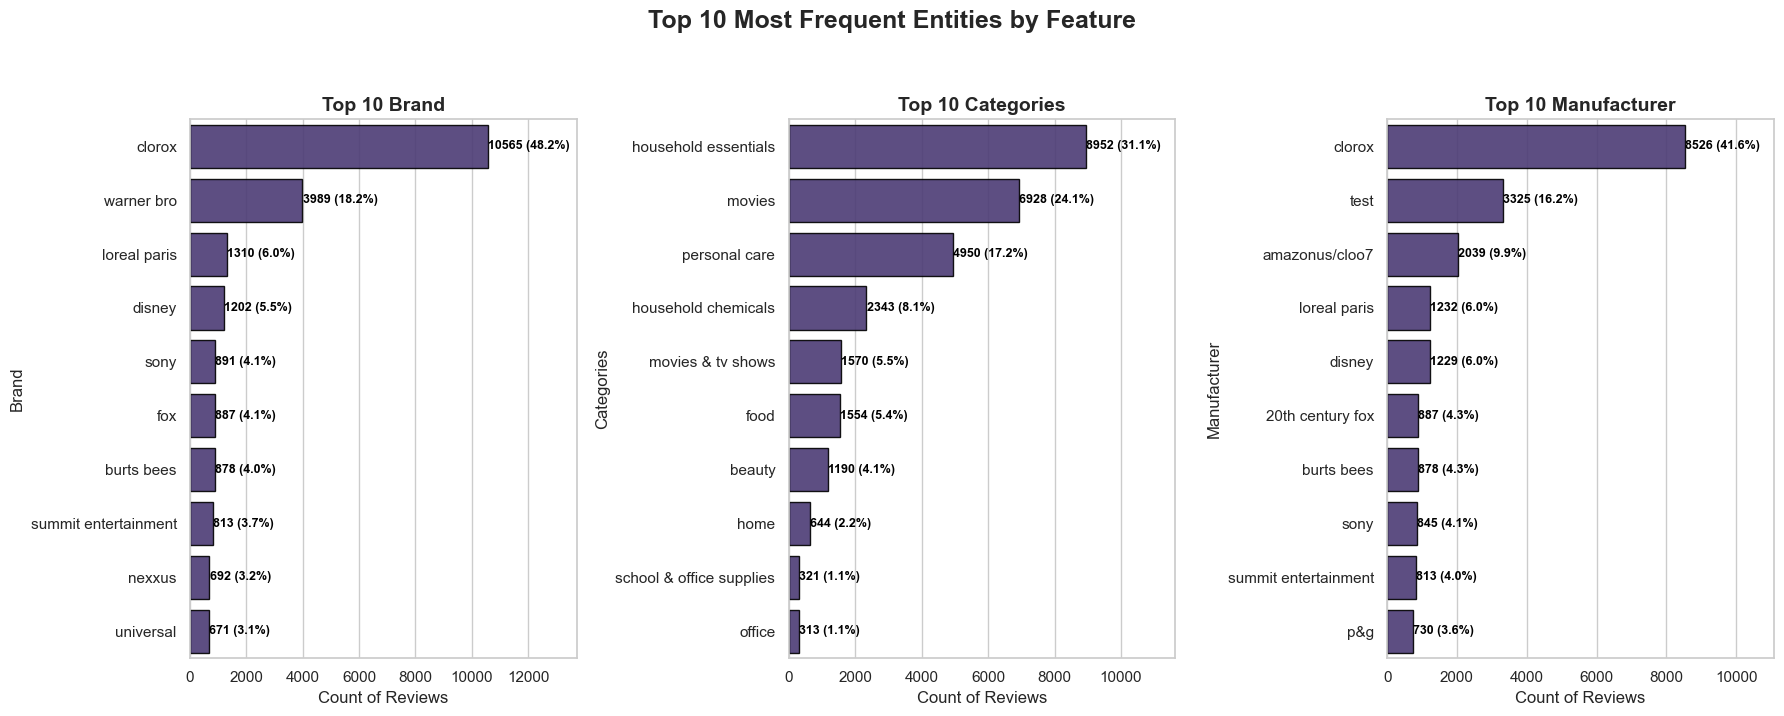

In [13]:
# Which are the top 10 most frequent brands, product categories, and manufacturers that dominate the dataset by count, and what is the degree of concentration for each feature?
plot_top_categorical_features(df, n_top=10)

In [14]:
def plot_text_length_distribution(df: pd.DataFrame):
    """Calculates and plots the distribution of character lengths for review text and title.

    Args:
        df: A pandas DataFrame containing 'reviews_text' and 'reviews_title' columns.
    """
    # 1. Calculate lengths
    df['text_length'] = df['reviews_text'].str.len()
    df['title_length'] = df['reviews_title'].str.len()

    # 2. Reshape data for plotting
    # Melt the DataFrame to a long format for easy comparison in a single plot
    length_df = df[['text_length', 'title_length']].melt(
        var_name='Feature',
        value_name='Length',
        ignore_index=False
    ).dropna() # Drop rows where length could not be calculated (NaN or missing original text)

    # 3. Set up the plot
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(12, 7))

    # Use a histogram with overlaid distributions (multiple='layer') and KDE
    # The 'bins' argument is calculated dynamically for better visualization across both ranges
    max_len = length_df['Length'].max()
    n_bins = min(50, int(np.sqrt(len(length_df)))) # Use square root rule for a reasonable bin count
    
    ax = sns.histplot(
        data=length_df,
        x='Length',
        hue='Feature',
        bins=n_bins,
        kde=True,
        multiple='layer',
        palette={'text_length': sns.color_palette("deep")[0], 'title_length': sns.color_palette("deep")[1]},
        alpha=0.6,
        line_kws={'linewidth': 3}
    )

    # Set Title and Labels
    ax.set_title(
        'Distribution of Review Text and Title Length (Characters)',
        fontsize=16,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('Length (Number of Characters)', fontsize=14)
    ax.set_ylabel('Frequency (Count)', fontsize=14)

    # Calculate and annotate mean lengths
    mean_text = df['text_length'].mean()
    mean_title = df['title_length'].mean()
    
    ax.axvline(mean_text, color=sns.color_palette("deep")[0], linestyle='--', linewidth=1.5, label=f'Mean Text Len: {mean_text:.1f}')
    ax.axvline(mean_title, color=sns.color_palette("deep")[1], linestyle='-.', linewidth=1.5, label=f'Mean Title Len: {mean_title:.1f}')
    
    # Update legend to reflect mean lines
    handles, labels = ax.get_legend_handles_labels()
    # Filter to only show the two mean line labels
    ax.legend(handles[-2:], labels[-2:], title='Feature Mean', loc='upper right')

    # Final aesthetic touches and saving
    plt.tight_layout()

    # Save and show the figure
    plt.savefig('text_length_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

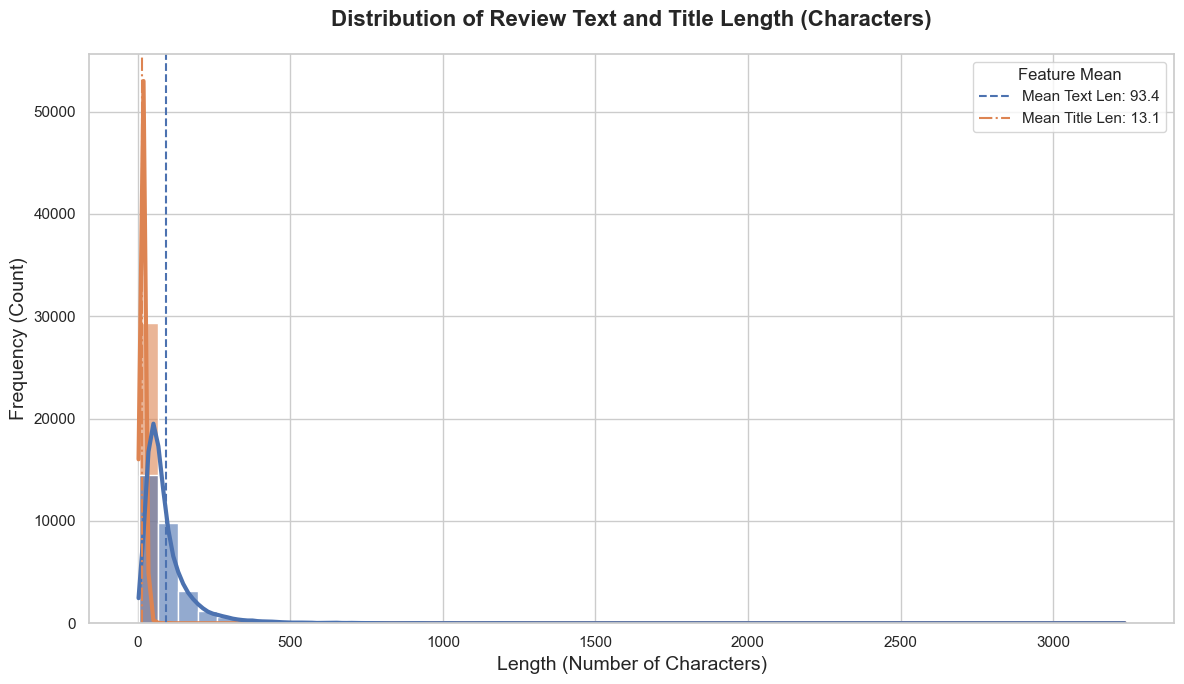

In [15]:
# How does the distribution of review text length compare to the distribution of review title length in terms of typical length, spread, and overall shape?
plot_text_length_distribution(df)

In [16]:
def plot_recommendation_rate(df: pd.DataFrame):
    """Creates and displays a count plot for the 'reviews_doRecommend' Boolean feature.

    This function visualizes the balance of positive versus negative recommendations.

    Args:
        df: A pandas DataFrame containing a 'reviews_doRecommend' column (Boolean or categorical).
    """
    # Ensure the feature is properly ordered and represented
    # Convert to string to ensure consistent axis labeling (e.g., 'True' vs 'False')
    df['reviews_doRecommend_str'] = df['reviews_doRecommend'].astype(str)
    
    # Define the order for the plot
    recommendation_order = ['True', 'False']
    
    # Define color palette: Green for True, Red/Orange for False
    palette_map = {'True': sns.color_palette("deep")[2], 'False': sns.color_palette("deep")[3]}

    # Set a professional style
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(8, 6))

    # Use seaborn.countplot for categorical data
    ax = sns.countplot(
        x='reviews_doRecommend_str',
        data=df,
        order=recommendation_order,
        palette=palette_map,
        edgecolor='black',
        alpha=0.9
    )

    # Set Title and Labels
    ax.set_title(
        'Distribution of Product Recommendation Status',
        fontsize=16,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('Product Recommended?', fontsize=14)
    ax.set_ylabel('Number of Reviews (Count)', fontsize=14)

    # Add counts and percentages on top of the bars
    total_reviews = len(df)
    for p in ax.patches:
        height = p.get_height()
        # Format the count and the percentage
        count = int(height)
        percentage = f'({100 * height / total_reviews:.1f}%)'

        ax.annotate(
            f'{count}\n{percentage}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=11,
            fontweight='bold'
        )

    # Final aesthetic touches and saving
    plt.xticks(rotation=0)
    plt.tight_layout()

    # Save and show the figure
    plt.savefig('recommendation_rate_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

C:\Users\outsi\AppData\Local\Temp\ipykernel_6640\1844925868.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


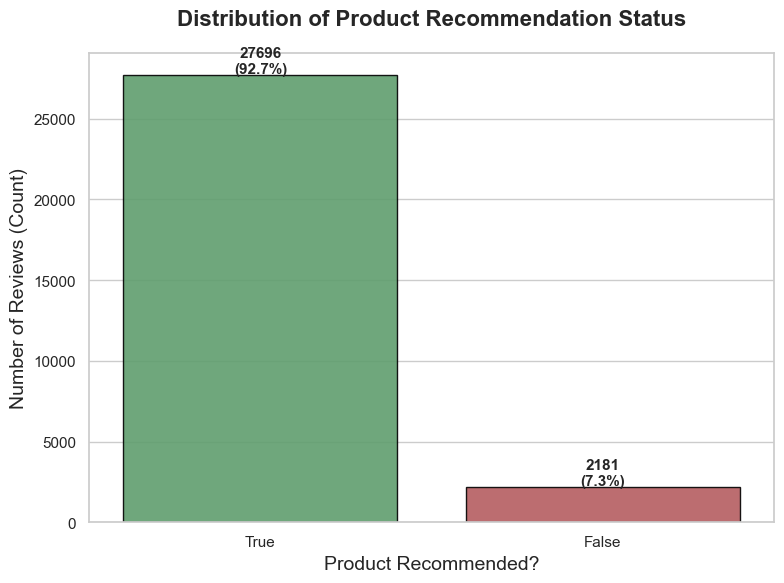

In [17]:
# What is the overall recommendation rate, and what is the exact proportion of users who recommend the product versus those who do not?
plot_recommendation_rate(df)

# 3. Bivariate & Multivariate Analysis (Feature Relationships) 🤝

In [18]:
def plot_rating_sentiment_relationship(df: pd.DataFrame):
    """Creates a normalized heatmap showing the distribution of sentiment within each star rating.

    Args:
        df: A pandas DataFrame containing 'reviews_rating' and 'user_sentiment' columns.
    """
    # 1. Create a normalized crosstab
    # normalize='index' ensures that each row (rating) sums to 1 (100%), showing the
    # percentage of sentiment FOR THAT RATING LEVEL.
    crosstab_norm = pd.crosstab(
        df['reviews_rating'],
        df['user_sentiment'],
        normalize='index'
    )
    
    # Ensure columns are in the desired order (Negative first for progressive color)
    crosstab_norm = crosstab_norm[['Negative', 'Positive']]

    # Convert percentages to string format for annotations
    crosstab_anno = (crosstab_norm * 100).round(1).astype(str) + '%'

    # 2. Set up the plot
    sns.set_theme(style="white")

    plt.figure(figsize=(9, 6))

    # Use a diverging color map to highlight the contrast (e.g., 'RdYlGn' or 'coolwarm')
    # Use 'coolwarm' where positive is warm (red) and negative is cool (blue).
    ax = sns.heatmap(
        crosstab_norm,
        annot=crosstab_anno,
        fmt='s', # Use string format for the percentage annotations
        cmap='coolwarm',
        linewidths=.5,
        linecolor='black',
        cbar_kws={'label': 'Proportion of Sentiment (Row Normalized)'},
        vmin=0, # Set min/max to 0 and 1 for clear proportion visualization
        vmax=1
    )

    # Set Title and Labels
    ax.set_title(
        'Sentiment Distribution by Review Rating (Row Normalized)',
        fontsize=16,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('User Sentiment', fontsize=14)
    ax.set_ylabel('Review Rating (Stars)', fontsize=14)
    
    # Rotate y-tick labels horizontally for better readability
    plt.yticks(rotation=0)

    # Final aesthetic touches and saving
    plt.tight_layout()

    # Save and show the figure
    plt.savefig('rating_vs_sentiment_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

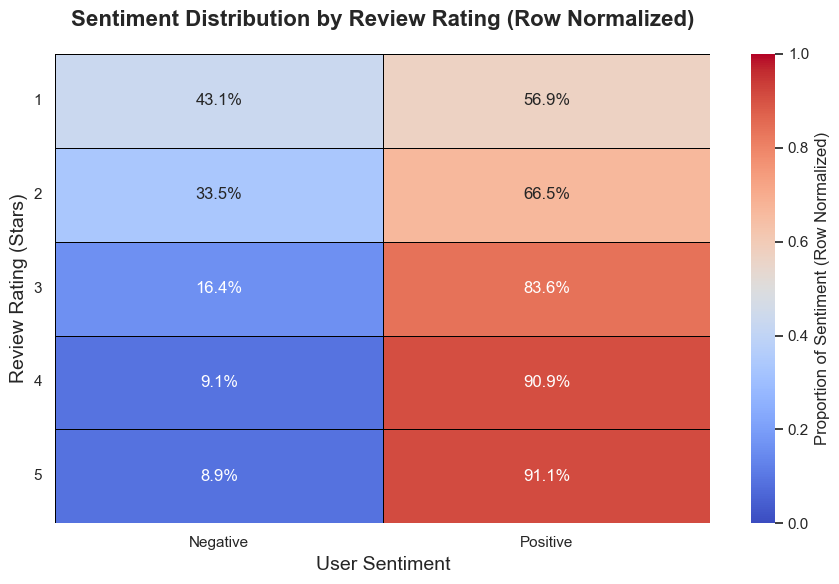

In [19]:
# What is the conditional probability of a review being labeled 'Positive' or 'Negative' at each discrete star rating level (1 through 5), and how well do the two metrics align?
plot_rating_sentiment_relationship(df)

In [20]:
def plot_recommendation_by_rating(df: pd.DataFrame):
    crosstab_norm = pd.crosstab(
        pd.to_numeric(df['reviews_rating']),
        df['reviews_doRecommend'],
        normalize='index'
    )

    crosstab_anno = (crosstab_norm * 100).round(1)

    # Map rating values to positional row index (0–4)
    rating_to_pos = {rating: pos for pos, rating in enumerate(crosstab_norm.index)}

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 7))

    colors = {
        False: sns.color_palette("deep")[3],
        True: sns.color_palette("deep")[2]
    }

    ax = crosstab_norm.plot(
        kind='bar',
        stacked=True,
        color=[colors[False], colors[True]],
        ax=plt.gca(),
        edgecolor='black'
    )

    ax.set_title('Proportion of Recommended Status by Star Rating', fontsize=16, fontweight='bold')
    ax.set_xlabel('Review Rating (Stars)', fontsize=14)
    ax.set_ylabel('Proportion of Reviews (%)', fontsize=14)

    ax.legend(
        title='Do Recommend',
        labels=['False (Not Recommended)', 'True (Recommended)'],
        loc='lower right'
    )

    # ---- FIXED ANNOTATIONS ----
    for bar in ax.patches:
        height = bar.get_height()
        if height == 0:
            continue

        width = bar.get_width()
        y = bar.get_y()

        # Get the rating from bar position (1..5)
        rating_value = round(bar.get_x() + width / 2)+1
        rating_index = rating_to_pos.get(rating_value)

        # Determine True/False by y-position
        # y = 0 → False, y > 0 → True (because False plotted first)
        is_recommended = bool(y > 0)

        # Lookup percentage
        percent = crosstab_anno.iloc[rating_index][is_recommended]

        if percent > 2:
            ax.text(
                bar.get_x() + width / 2,
                y + height / 2,
                f"{percent:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold'
            )

    plt.xticks(rotation=0)
    ax.set_yticklabels(['{:,.0%}'.format(x) for x in ax.get_yticks()])
    plt.tight_layout()
    plt.show()


C:\Users\outsi\AppData\Local\Temp\ipykernel_6640\2177780432.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(x) for x in ax.get_yticks()])


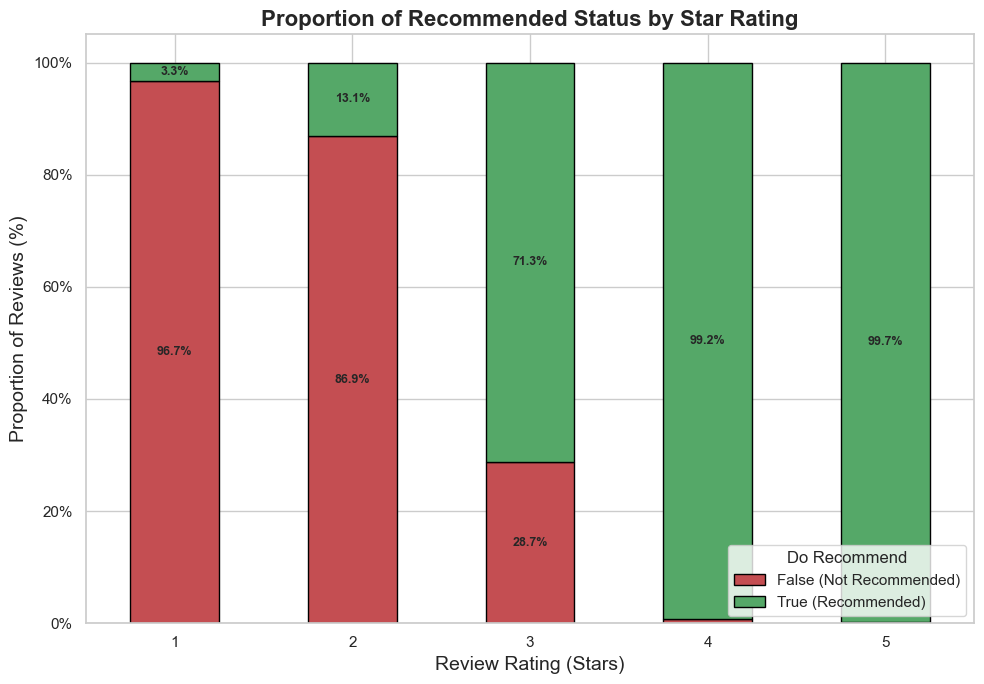

In [21]:
# How does the probability of a user recommending the product change across the 5-point star rating scale, 
# and at what rating does the majority of users switch from 'Not Recommended' to 'Recommended'?
plot_recommendation_by_rating(df)

In [22]:
def calculate_sentiment_ratio(series: pd.Series) -> float:
    """Calculates the ratio of Positive to Negative sentiment, handling division by zero."""
    pos_count = (series == 'Positive').sum()
    neg_count = (series == 'Negative').sum()
    
    if neg_count == 0:
        # Use a very large number for cases with perfect positive sentiment
        return 1e6 
    return pos_count / neg_count

def analyze_and_plot_top_brands(df: pd.DataFrame, n_top: int = 10):
    """Groups data by categories and brand, calculates performance metrics, and plots the top brands.

    Args:
        df: A pandas DataFrame containing 'reviews_rating', 'user_sentiment', 'categories', and 'brand'.
        n_top: The number of top entities to display in the plot.
    """
    df['reviews_rating'] = df['reviews_rating'].astype(float)
    # 1. Perform Aggregation
    agg_df = df.groupby(['categories', 'brand']).agg(
        average_rating=('reviews_rating', 'mean'),
        total_reviews=('reviews_rating', 'count'),
        sentiment_ratio=('user_sentiment', calculate_sentiment_ratio)
    ).reset_index()

    # Rename the column for the ratio and round average rating
    agg_df['average_rating'] = agg_df['average_rating'].round(2)
    agg_df['positive_to_negative_ratio'] = agg_df['sentiment_ratio'].round(2)
    agg_df = agg_df.drop(columns=['sentiment_ratio'])
    
    # Sort and filter for top N brands based on average rating
    # Filter by total_reviews > a threshold to avoid volatile averages from low sample sizes
    min_reviews_threshold = agg_df['total_reviews'].quantile(0.2)
    
    top_brands_df_filtered = agg_df[agg_df['total_reviews'] >= min_reviews_threshold].copy()
    
    # Create a composite label for the y-axis (Brand - Category)
    top_brands_df_filtered['entity_label'] = top_brands_df_filtered['brand'] + ' (' + top_brands_df_filtered['categories'] + ')'
    
    # Sort the filtered DataFrame once
    top_brands_df_sorted = (
        top_brands_df_filtered
        .sort_values(by='average_rating', ascending=False)
        .head(n_top)
        .reset_index(drop=True)
    )
    # print("Full brand performance analysis saved to brand_performance_analysis.csv")

    # 2. Set up the plot (Top N Brands by Average Rating)
    sns.set_theme(style="whitegrid", palette="viridis")

    plt.figure(figsize=(12, 15))

    # Use a horizontal bar plot for readability
    ax = sns.barplot(
        x='average_rating',
        y='entity_label',
        data=top_brands_df_sorted, # Use sorted data
        edgecolor='black',
        alpha=0.8
    )

    # Set Title and Labels
    ax.set_title(
        f'Top {n_top} Performing Brand/Category Entities by Average Rating',
        fontsize=16,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('Average Review Rating', fontsize=12)
    ax.set_ylabel('Brand/Category Entity', fontsize=12)
    
    # Add annotations (average rating and total reviews)
    for i, row in top_brands_df_sorted.iterrows():
        rating = row['average_rating']
        count = row['total_reviews']
        
        ax.text(
            rating + 0.02,  # x coordinate (value + offset)
            i,              # y coordinate (bar index)
            f'{rating:.2f} (n={count})',
            ha='left',
            va='center',
            fontsize=10,
            fontweight='bold'
        )

    # Set x-axis limit slightly higher than max rating for annotation space
    ax.set_xlim(3.0, 5.0)
    
    # Add a reference line for the mean overall rating
    overall_mean = df['reviews_rating'].mean()
    ax.axvline(overall_mean, color='red', linestyle='--', linewidth=1.5, label=f'Overall Mean Rating: {overall_mean:.2f}')
    
    ax.legend(loc='lower right')

    # Final aesthetic touches and saving
    plt.tight_layout()

    # Save and show the figure
    plt.savefig('top_performing_brands_by_rating.png', dpi=600, bbox_inches='tight')
    plt.show()

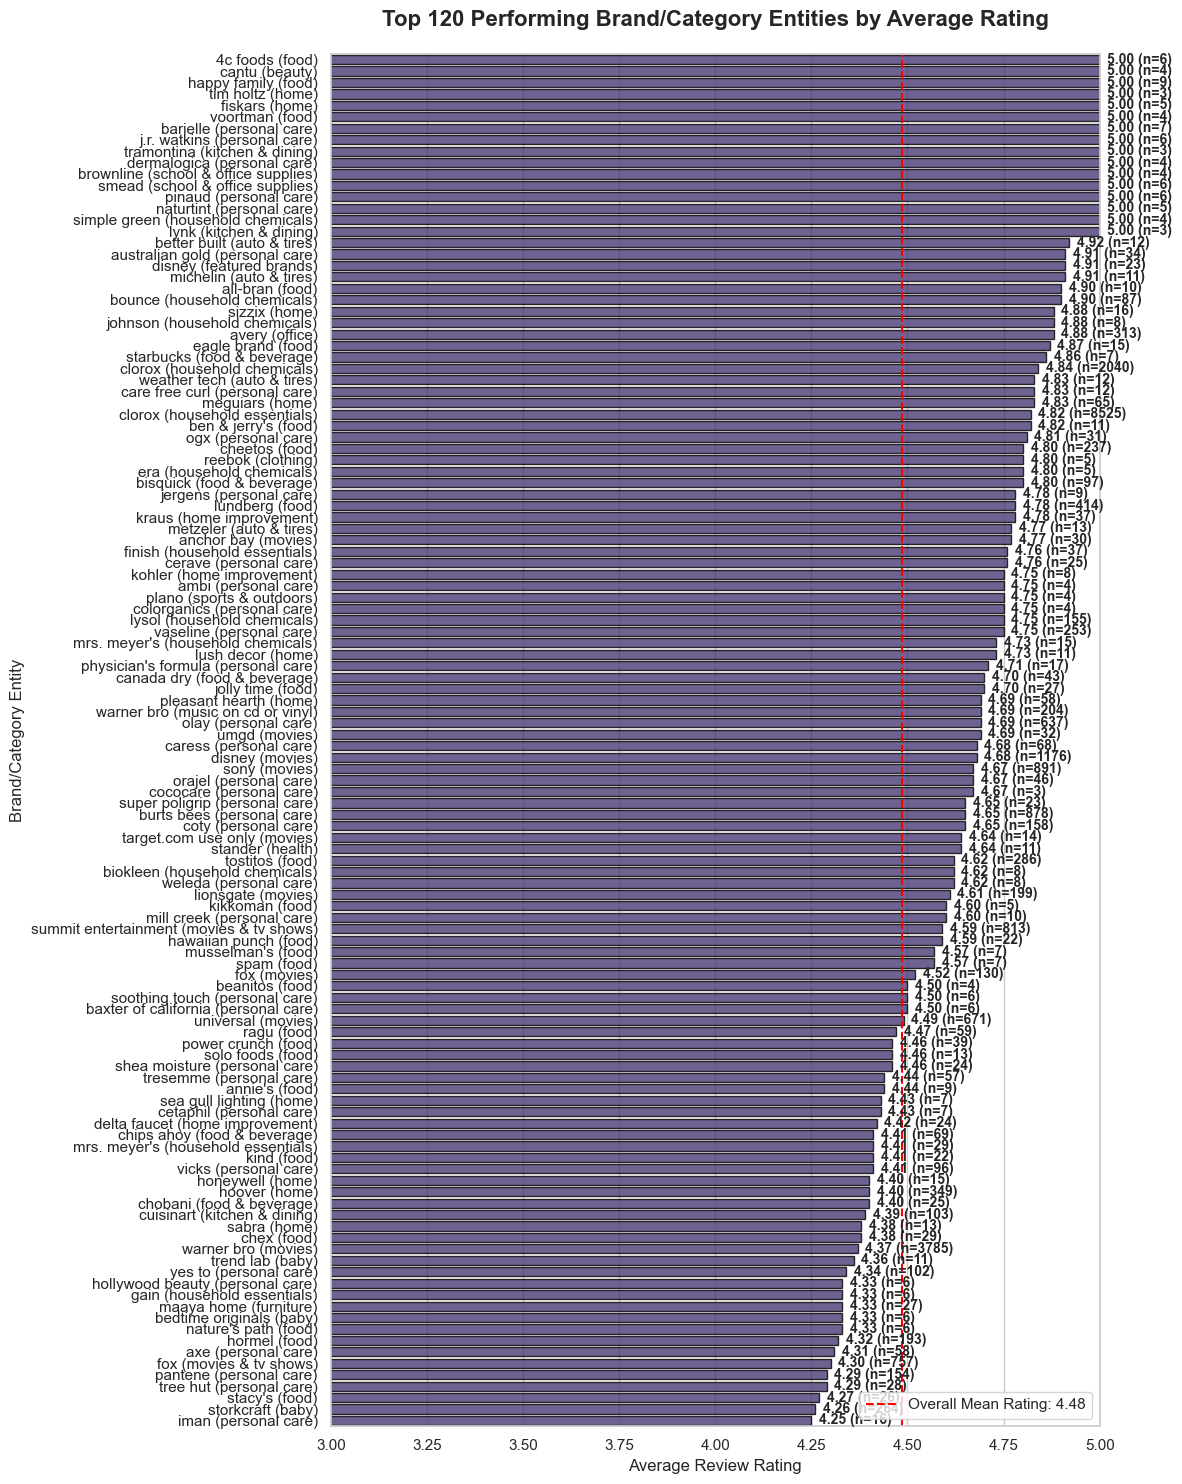

In [23]:
# Which are the top 10 brands, ranked by their average review rating, and how does their performance vary across the rating scale?
analyze_and_plot_top_brands(df, 120)

# 4. Text-Specific EDA (Natural Language Processing) 💬

In [31]:
def generate_sentiment_word_clouds(df: pd.DataFrame):
    """Generates and displays two word clouds: one for positive review texts and one for negative.

    Args:
        df: A pandas DataFrame containing 'user_sentiment' and 'reviews_text' columns.
    """
    # 1. Prepare Text Data
    positive_reviews = " ".join(df[df['user_sentiment'] == 'Positive']['reviews_text'].dropna().tolist())
    negative_reviews = " ".join(df[df['user_sentiment'] == 'Negative']['reviews_text'].dropna().tolist())

    # Check if there's enough text to generate word clouds
    if not positive_reviews:
        print("Warning: No positive review text found for word cloud generation.")
        return
    if not negative_reviews:
        print("Warning: No negative review text found for word cloud generation.")
        return

    # Define common stop words (can be extended based on domain)
    stopwords = set(WordCloud().stopwords)
    stopwords.update(['product', 'review', 'use', 'just', 'get', 'like', 'one', 'would', 'really', 'much', 'time'])

    # 2. Generate Word Clouds
    wordcloud_positive = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=stopwords,
        min_font_size=10,
        colormap='Blues' # Green for positive
    ).generate(positive_reviews)

    wordcloud_negative = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=stopwords,
        min_font_size=10,
        colormap='Reds' # Red for negative
    ).generate(negative_reviews)

    # 3. Plotting
    plt.figure(figsize=(16, 8))

    # Positive Word Cloud
    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(wordcloud_positive, interpolation='bilinear')
    ax1.set_title('Most Frequent Words in Positive Reviews', fontsize=16, fontweight='bold', pad=15)
    ax1.axis('off')

    # Negative Word Cloud
    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(wordcloud_negative, interpolation='bilinear')
    ax2.set_title('Most Frequent Words in Negative Reviews', fontsize=16, fontweight='bold', pad=15)
    ax2.axis('off')

    plt.tight_layout()

    # Save and show the figure
    plt.savefig('sentiment_word_clouds.png', dpi=300, bbox_inches='tight')
    plt.show()

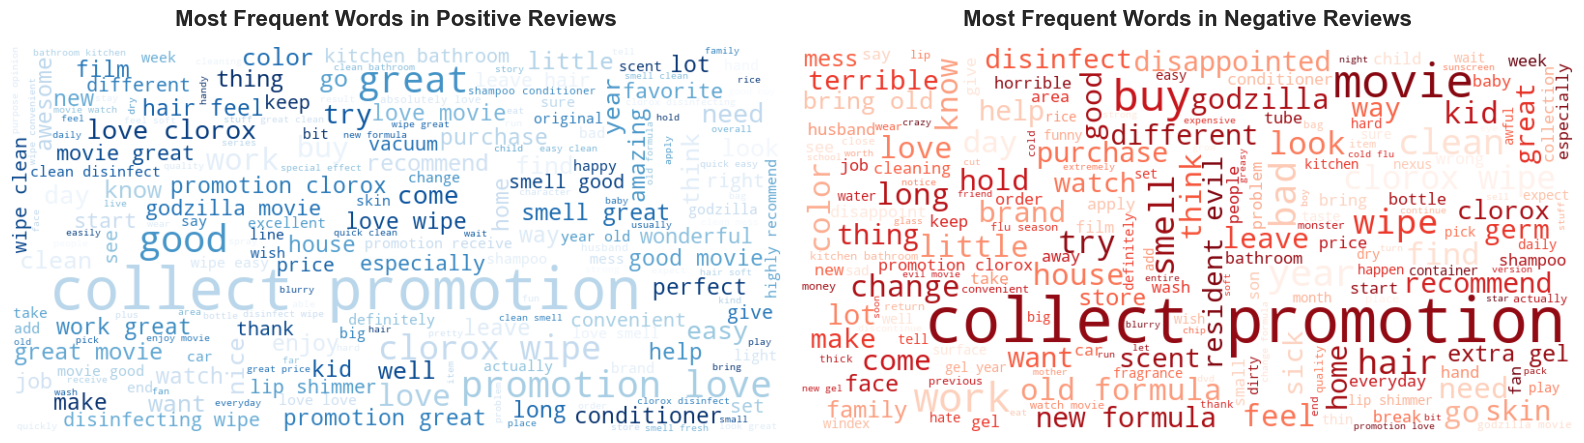

In [32]:
# What are the most prominent and frequently used words in positive review texts compared 
# to negative review texts, visually representing key drivers of each sentiment?
generate_sentiment_word_clouds(df)

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus: pd.Series, ngram_range: tuple[int, int], n: int = 15) -> pd.DataFrame:
    """Calculates the top N most frequent N-grams in a text corpus."""
    # Use CountVectorizer for efficient tokenization, stop word removal, and N-gram generation
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        stop_words='english',
        token_pattern=r'\b[a-zA-Z]{2,}\b' # Filter tokens shorter than 2 chars
    )
    
    # Fit and transform the corpus
    X = vectorizer.fit_transform(corpus.astype(str).dropna())
    
    # Get feature names (the N-grams) and their counts
    feature_names = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1
    
    # Create DataFrame for analysis
    ngram_df = pd.DataFrame(counts, index=feature_names, columns=['count']).sort_values(
        by='count', ascending=False
    ).head(n)
    
    return ngram_df.reset_index().rename(columns={'index': 'ngram'})

def perform_ngram_analysis(df: pd.DataFrame, text_col: str = 'reviews_text', n_top: int = 15):
    """Finds and plots the top unigrams, and calculates top bigrams and trigrams."""
    
    corpus = df[text_col]

    # 1. Calculate N-grams (results were printed/saved in execution block)
    top_unigrams_df = get_top_ngrams(corpus, ngram_range=(1, 1), n=n_top)
    # top_bigrams_df = get_top_ngrams(corpus, ngram_range=(2, 2), n=n_top)
    # top_trigrams_df = get_top_ngrams(corpus, ngram_range=(3, 3), n=n_top)

    # 2. Plotting (Focusing on Unigrams as the primary visualization)
    sns.set_theme(style="whitegrid", palette="viridis")

    plt.figure(figsize=(10, 7))

    # Reverse order for better readability on horizontal plot (highest count at top)
    plot_df = top_unigrams_df.sort_values(by='count', ascending=True)

    ax = sns.barplot(
        x='count',
        y='ngram',
        data=plot_df,
        edgecolor='black',
        alpha=0.8
    )

    # Set Title and Labels
    ax.set_title(
        f'Top {n_top} Most Frequent Unigrams (Single Words)',
        fontsize=16,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('Total Count', fontsize=14)
    ax.set_ylabel('Word (Unigram)', fontsize=14)
    
    # Add annotations for count
    for p in ax.patches:
        count = p.get_width()
        
        ax.text(
            count + 15, # x coordinate (value + offset)
            p.get_y() + p.get_height() / 2, # y coordinate (center of the bar)
            f'{int(count)}',
            ha='left',
            va='center',
            fontsize=10,
            fontweight='bold'
        )

    # Final aesthetic touches and saving
    plt.tight_layout()

    # Save and show the figure
    plt.savefig('top_unigrams_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

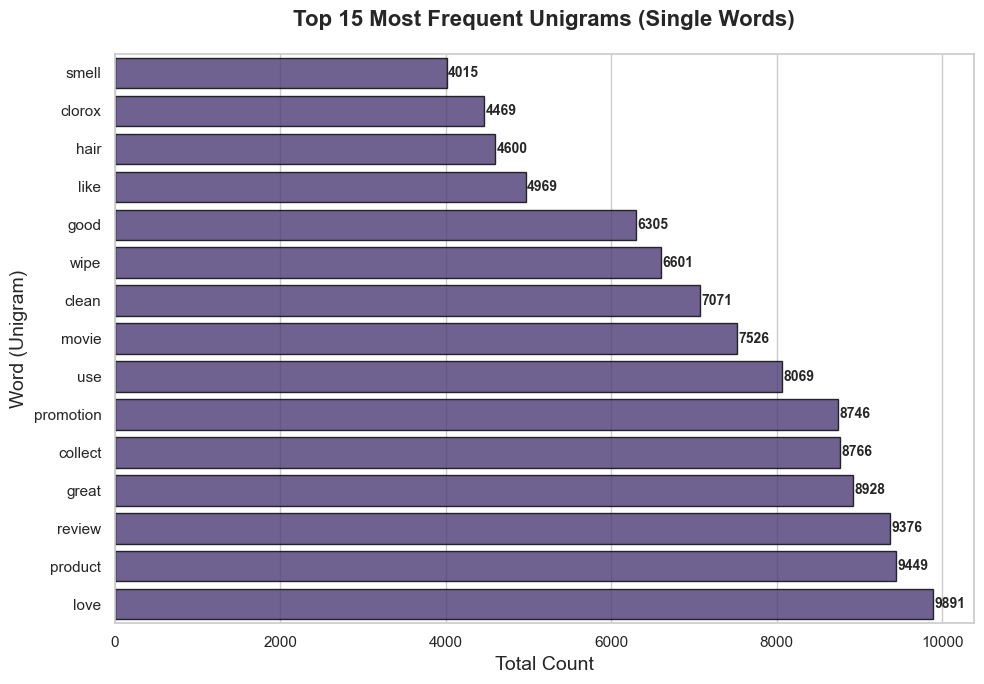

In [41]:
# What are the 15 most frequently used single words (unigrams) in the review texts after filtering for common English stop words?
perform_ngram_analysis(df, text_col = 'reviews_text', n_top= 15)


In [46]:
import re

def plot_vocabulary_growth(df: pd.DataFrame):
    """Calculates and plots the cumulative growth of unique vocabulary size in a corpus.

    This graph visualizes the relationship between the total number of words read
    and the number of unique words found (Heaps' Law).

    Args:
        df: A pandas DataFrame containing a 'reviews_text' column.
    """
    # 1. Preprocess and Tokenize Corpus
    # Join all texts into a single string
    full_text = ' '.join(df['reviews_text'].astype(str).dropna().tolist())

    # Simple tokenization: lowercase, keep only words (remove punctuation/numbers)
    tokens = re.findall(r'\b[a-z]{2,}\b', full_text.lower())
    
    if not tokens:
        print("Error: Could not extract valid tokens from the review text.")
        return

    # 2. Calculate Cumulative Vocabulary Growth
    cumulative_tokens = []
    cumulative_unique_tokens = []
    seen_words = set()
    token_count = 0
    
    for token in tokens:
        token_count += 1
        seen_words.add(token)
        cumulative_tokens.append(token_count)
        cumulative_unique_tokens.append(len(seen_words))
        
    # Convert results to a DataFrame for plotting
    plot_data = pd.DataFrame({
        'Total Words': cumulative_tokens,
        'Unique Vocabulary Size': cumulative_unique_tokens
    })
    
    final_vocabulary_size = plot_data['Unique Vocabulary Size'].iloc[-1]
    total_words_count = plot_data['Total Words'].iloc[-1]

    # 3. Plotting
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(10, 6))

    ax = sns.lineplot(
        x='Total Words',
        y='Unique Vocabulary Size',
        data=plot_data,
        linewidth=2.5,
        color=sns.color_palette("deep")[0]
    )

    # Add title and labels
    ax.set_title(
        'Cumulative Vocabulary Growth (Heaps\' Law)',
        fontsize=16,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('Total Words Processed', fontsize=14)
    ax.set_ylabel('Cumulative Unique Words (Vocabulary Size)', fontsize=14)
    
    # Annotate the final vocabulary size
    ax.axhline(
        final_vocabulary_size, 
        color='red', 
        linestyle='--', 
        linewidth=1, 
        label=f'Final Vocabulary Size: {final_vocabulary_size:,}'
    )
    
    ax.legend(loc='lower right')

    # Final aesthetic touches and saving
    plt.tight_layout()

    # Save and show the figure
    plt.savefig('vocabulary_growth_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

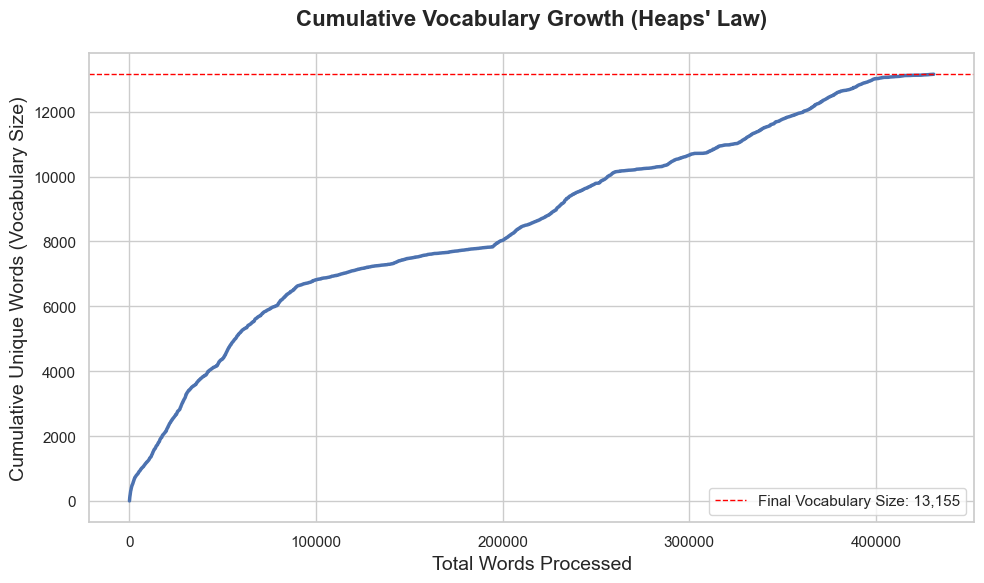

In [47]:
# How does the total number of unique words (vocabulary size) grow cumulatively as more words are processed from the review corpus?
plot_vocabulary_growth(df)

# 5. Summary and Key Insights